# Polynomial Regression
*Course package generated on 2025-09-07.*

**Mục tiêu học tập**
- Hiểu nguyên lý và công thức chính.
- Áp dụng trên dữ liệu uy tín (gói `scikit-learn` – nguồn gốc UCI hoặc bộ tổng hợp chuẩn).
- Đánh giá bằng metric phù hợp và trực quan hóa bằng **matplotlib**.
- Thực hành, mở rộng qua bài tập cuối notebook.


**Ý tưởng**: mở rộng đặc trưng bậc cao rồi áp Linear Regression trên không gian mới.


Degree=1 -> RMSE=0.3352, R2=-0.0128
Degree=3 -> RMSE=0.3028, R2=0.1734
Degree=5 -> RMSE=0.1996, R2=0.6409


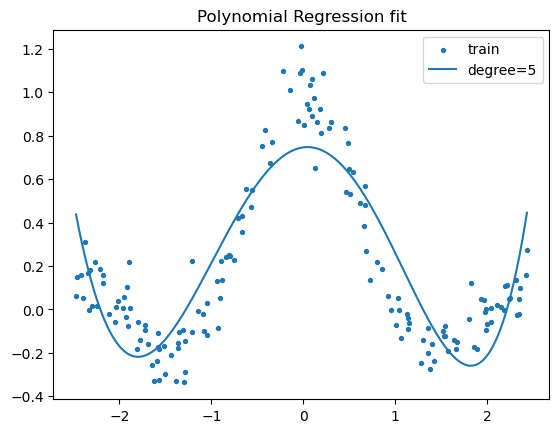

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score  # vẫn dùng được

# --- Hàm RMSE thuần NumPy (version-agnostic) ---
def rmse_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))
#
rng = np.random.RandomState(42)
X = np.sort(5 * rng.rand(200, 1) - 2.5, axis=0)
y = np.sinc(X).ravel() + 0.1 * rng.randn(200)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

for d in [1, 3, 5]:
    model = Pipeline([
        ("poly",   PolynomialFeatures(degree=d, include_bias=False)),
        ("scaler", StandardScaler()),
        ("linreg", LinearRegression())
    ]).fit(X_train, y_train)

    pred = model.predict(X_test)
    rmse = rmse_np(y_test, pred)
    r2   = r2_score(y_test, pred)
    print(f"Degree={d} -> RMSE={rmse:.4f}, R2={r2:.4f}")

xx = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
model = Pipeline([
    ("poly",   PolynomialFeatures(degree=5, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
]).fit(X_train, y_train)

yy = model.predict(xx)
fig, ax = plt.subplots()
ax.scatter(X_train, y_train, s=8, label="train")
ax.plot(xx, yy, label="degree=5")
ax.set_title("Polynomial Regression fit")
ax.legend()
plt.show()


**Bài tập**
- So sánh RMSE với degree = 1..10; phát hiện overfitting.
- Dùng cross-validation để chọn degree tối ưu.


deg | Train RMSE | Test RMSE | Test R2 | CV RMSE (mean±std)
  1 |     0.3844 |    0.3352 | -0.0128 |   0.3859 ± 0.0209
  2 |     0.3272 |    0.3073 |  0.1485 |   0.3310 ± 0.0079
  3 |     0.3251 |    0.3028 |  0.1734 |   0.3293 ± 0.0092
  4 |     0.1864 |    0.2022 |  0.6314 |   0.1918 ± 0.0273
  5 |     0.1854 |    0.1996 |  0.6409 |   0.1929 ± 0.0262
  6 |     0.1056 |    0.1126 |  0.8856 |   0.1068 ± 0.0213
  7 |     0.1052 |    0.1147 |  0.8814 |   0.1074 ± 0.0234
  8 |     0.0921 |    0.1096 |  0.8918 |   0.0949 ± 0.0224
  9 |     0.0918 |    0.1080 |  0.8948 |   0.0946 ± 0.0220
 10 |     0.0917 |    0.1079 |  0.8950 |   0.0951 ± 0.0216

Best degree (min CV RMSE): 9
1-SE rule degree (đơn giản hơn, gần tối ưu): 6


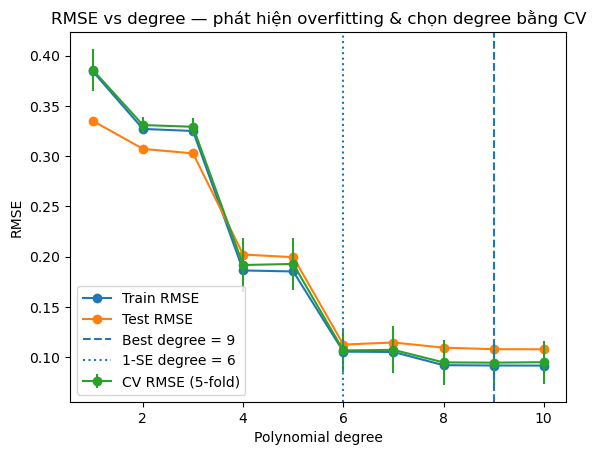

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- RMSE NumPy ---
def rmse_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# --- Synthetic data (như ví dụ của bạn) ---
rng = np.random.RandomState(42)
X = np.sort(5 * rng.rand(200, 1) - 2.5, axis=0)
y = np.sinc(X).ravel() + 0.1 * rng.randn(200)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

degrees = range(1, 11)
rmse_tr, rmse_te, r2_te = [], [], []
cv_mean, cv_std = [], []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for d in degrees:
    pipe = Pipeline([
        ("poly",   PolynomialFeatures(degree=d, include_bias=False)),
        ("scaler", StandardScaler()),
        ("linreg", LinearRegression())
    ])
    # Fit trên train
    pipe.fit(X_train, y_train)

    # Train/Test RMSE + R2
    yhat_tr = pipe.predict(X_train)
    yhat_te = pipe.predict(X_test)
    rmse_tr.append(rmse_np(y_train, yhat_tr))
    rmse_te.append(rmse_np(y_test,  yhat_te))
    r2_te.append(r2_score(y_test, yhat_te))

    # CV 5-fold trên tập train (điểm = neg MSE → RMSE)
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=kf, scoring="neg_mean_squared_error", n_jobs=-1)
    rmse_cv = np.sqrt(-scores)
    cv_mean.append(rmse_cv.mean())
    cv_std.append(rmse_cv.std())

# Chọn degree tối ưu theo CV-mean nhỏ nhất
best_idx = int(np.argmin(cv_mean))
best_deg = list(degrees)[best_idx]

# Quy tắc 1-SE: chọn degree nhỏ nhất có CV-mean <= (min + std của degree tốt nhất)
one_se_threshold = cv_mean[best_idx] + cv_std[best_idx]
deg_1se = next(d for d, m in zip(degrees, cv_mean) if m <= one_se_threshold)

# In bảng kết quả
print("deg | Train RMSE | Test RMSE | Test R2 | CV RMSE (mean±std)")
for d, tr, te, r2, m, s in zip(degrees, rmse_tr, rmse_te, r2_te, cv_mean, cv_std):
    print(f"{d:>3} | {tr:10.4f} | {te:9.4f} | {r2:7.4f} | {m:8.4f} ± {s:.4f}")

print(f"\nBest degree (min CV RMSE): {best_deg}")
print(f"1-SE rule degree (đơn giản hơn, gần tối ưu): {deg_1se}")

# --- Vẽ đường cong để quan sát overfitting ---
plt.figure()
plt.plot(degrees, rmse_tr, marker="o", label="Train RMSE")
plt.plot(degrees, rmse_te, marker="o", label="Test RMSE")
plt.errorbar(degrees, cv_mean, yerr=cv_std, marker="o", linestyle="-", label="CV RMSE (5-fold)")
plt.axvline(best_deg, linestyle="--", label=f"Best degree = {best_deg}")
plt.axvline(deg_1se, linestyle=":",  label=f"1-SE degree = {deg_1se}")
plt.xlabel("Polynomial degree"); plt.ylabel("RMSE")
plt.title("RMSE vs degree — phát hiện overfitting & chọn degree bằng CV")
plt.legend()
plt.show()